# GLD (Gold ETF) — VIX-Style Volatility Index Demo

This notebook demonstrates:
1. VIX calculation for GLD options
2. Implied volatility surface construction
3. Skew analysis (Risk Reversal & Butterfly 25Δ)
4. Variance decomposition by strike
5. Backtest results overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.vix_index import vix_index_equity, fill_cmt_missing_dates, get_rate_for_maturity
from src.vix_index import compute_forward_and_k0, build_qk, compute_sigma2, _select_bracketing_expirations
from src.implied_vol import build_iv_surface, calibrate_svi, svi_raw
from src.skew import compute_skew_metrics
from src.greeks import variance_decomposition

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [2]:
options = pd.read_csv("data/gld_options_daily.csv")
options["tradeDate"] = pd.to_datetime(options["tradeDate"])
options["expirationDate"] = pd.to_datetime(options["expirationDate"])

rates = pd.read_csv("data/treasury yield curve rates.csv")
rates["Date"] = pd.to_datetime(rates["Date"])

calendar = pd.read_csv("data/cme holidays.csv")

print(f"Options: {len(options):,} rows")
print(f"Trade dates: {options['tradeDate'].nunique()}")
print(f"Date range: {options['tradeDate'].min().date()} → {options['tradeDate'].max().date()}")

Options: 800,067 rows
Trade dates: 502
Date range: 2024-02-20 → 2026-02-19


## 2. Calculate GLD VIX

In [3]:
trade_date = "2025-01-16"

result = vix_index_equity(
    options_df=options,
    rates_df=rates,
    calendar_df=calendar,
    trade_date=trade_date,
    target_days=30,
    price_scale=1.0,
)

print(f"GLD VIX (30-day): {result['vix']:.2f}%")
print(f"\nNear-term (exp: {result['near_exp'].date()}, T={result['T1']*365:.0f}d):")
print(f"  Forward: {result['F1']:.2f}, K₀: {result['K0_1']:.0f}, σ² = {result['sigma2_1']:.4f}")
print(f"\nNext-term (exp: {result['next_exp'].date()}, T={result['T2']*365:.0f}d):")
print(f"  Forward: {result['F2']:.2f}, K₀: {result['K0_2']:.0f}, σ² = {result['sigma2_2']:.4f}")

GLD VIX (30-day): 16.32%

Near-term (exp: 2025-02-14, T=29d):
  Forward: 251.10, K₀: 251, σ² = 0.0270

Next-term (exp: 2025-02-21, T=36d):
  Forward: 251.48, K₀: 251, σ² = 0.0248


## 3. Implied Volatility Surface

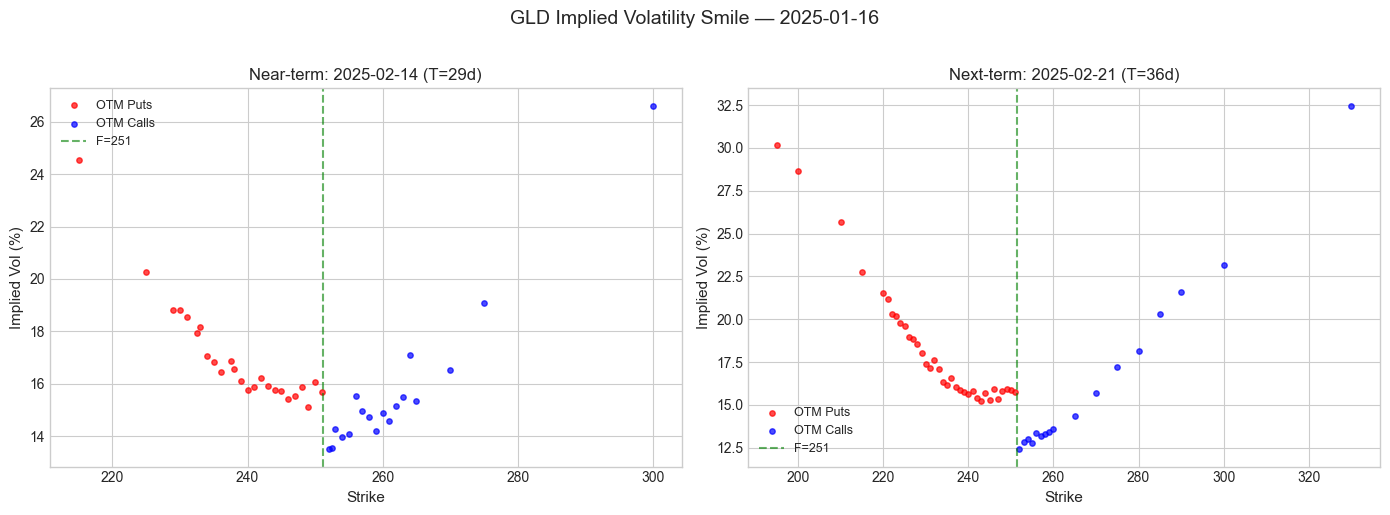

In [4]:
# Build IV slices for near and next expirations
td = pd.Timestamp(trade_date)
mask = options["tradeDate"] == td
opts_day = options.loc[mask].copy()

near_exp = result['near_exp']
next_exp = result['next_exp']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, exp, F, T, r_val, label in [
    (axes[0], near_exp, result['F1'], result['T1'], result['r1'], 'Near-term'),
    (axes[1], next_exp, result['F2'], result['T2'], result['r2'], 'Next-term'),
]:
    slice_df = opts_day[opts_day['expirationDate'] == exp]
    iv_surface = build_iv_surface(
        slice_df, forward=F, T=T, r=r_val,
        strike_col='strikePrice', type_col='optionType', price_col='settlement'
    )
    if not iv_surface.empty:
        calls = iv_surface[iv_surface['option_type'] == 'call']
        puts = iv_surface[iv_surface['option_type'] == 'put']
        ax.scatter(puts['strike'], puts['iv'] * 100, color='red', s=15, label='OTM Puts', alpha=0.7)
        ax.scatter(calls['strike'], calls['iv'] * 100, color='blue', s=15, label='OTM Calls', alpha=0.7)
        ax.axvline(x=F, color='green', linestyle='--', alpha=0.6, label=f'F={F:.0f}')
        ax.set_xlabel('Strike', fontsize=11)
        ax.set_ylabel('Implied Vol (%)', fontsize=11)
        ax.set_title(f'{label}: {exp.date()} (T={T*365:.0f}d)', fontsize=12)
        ax.legend(fontsize=9)

fig.suptitle(f'GLD Implied Volatility Smile — {trade_date}', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4. SVI Calibration

SVI Parameters (near-term 2025-02-14):
  a: 0.000587
  b: 0.024729
  rho: -0.199208
  m: -0.015576
  sigma: 0.041049
  RMSE: 0.000282


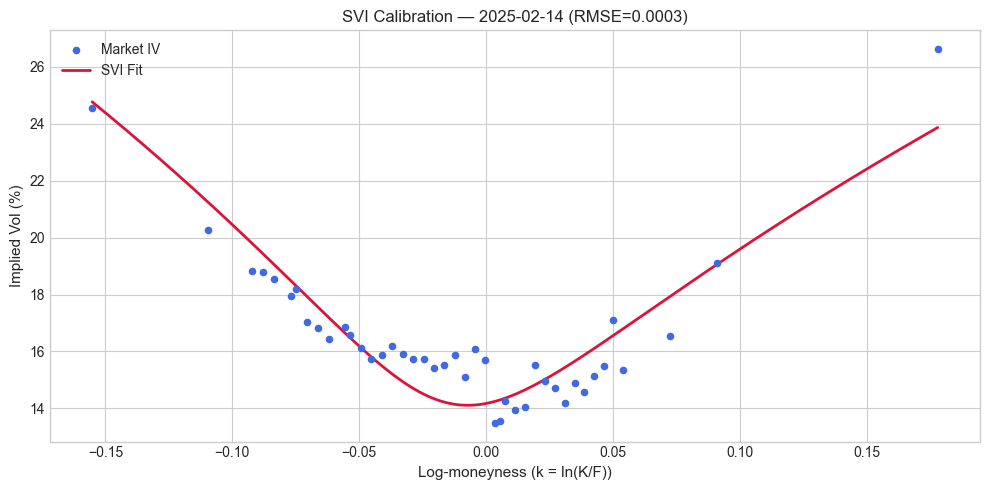

In [5]:
# Calibrate SVI on the near-term slice
slice_df = opts_day[opts_day['expirationDate'] == near_exp]
T_near = result['T1']
iv_data = build_iv_surface(
    slice_df, forward=result['F1'], T=T_near, r=result['r1'],
    strike_col='strikePrice', type_col='optionType', price_col='settlement'
)

if len(iv_data) >= 5:
    k = iv_data['moneyness'].values
    w = (iv_data['iv'].values ** 2) * T_near  # total variance
    svi_params = calibrate_svi(k, w)
    
    print(f"SVI Parameters (near-term {near_exp.date()}):")
    for p in ['a', 'b', 'rho', 'm', 'sigma']:
        print(f"  {p}: {svi_params[p]:.6f}")
    print(f"  RMSE: {svi_params['rmse']:.6f}")
    
    # Plot SVI fit
    k_grid = np.linspace(k.min(), k.max(), 200)
    w_fit = svi_raw(k_grid, **{p: svi_params[p] for p in ['a', 'b', 'rho', 'm', 'sigma']})
    iv_fit = np.sqrt(w_fit / T_near) * 100
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(k, np.sqrt(w / T_near) * 100, color='royalblue', s=20, label='Market IV', zorder=3)
    ax.plot(k_grid, iv_fit, color='crimson', linewidth=2, label='SVI Fit')
    ax.set_xlabel('Log-moneyness (k = ln(K/F))', fontsize=11)
    ax.set_ylabel('Implied Vol (%)', fontsize=11)
    ax.set_title(f'SVI Calibration — {near_exp.date()} (RMSE={svi_params["rmse"]:.4f})', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for SVI calibration")

## 5. Skew Analysis

In [6]:
if len(iv_data) >= 5:
    metrics = compute_skew_metrics(iv_data, forward=result['F1'], T=T_near, r=result['r1'])
    print(f"Skew Metrics for {near_exp.date()}:")
    print(f"  ATM Vol:       {metrics['atm_vol']*100:.2f}%" if np.isfinite(metrics['atm_vol']) else "  ATM Vol:       N/A")
    print(f"  25Δ Call Vol:  {metrics['call_25d_vol']*100:.2f}%" if np.isfinite(metrics.get('call_25d_vol', np.nan)) else "  25Δ Call Vol:  N/A")
    print(f"  25Δ Put Vol:   {metrics['put_25d_vol']*100:.2f}%" if np.isfinite(metrics.get('put_25d_vol', np.nan)) else "  25Δ Put Vol:   N/A")
    print(f"  Risk Reversal: {metrics['rr25']*100:.2f}%" if np.isfinite(metrics['rr25']) else "  Risk Reversal: N/A")
    print(f"  Butterfly:     {metrics['bf25']*100:.2f}%" if np.isfinite(metrics['bf25']) else "  Butterfly:     N/A")
else:
    print("Not enough IV data for skew analysis")

Skew Metrics for 2025-02-14:
  ATM Vol:       13.51%
  25Δ Call Vol:  14.30%
  25Δ Put Vol:   15.73%
  Risk Reversal: -1.43%
  Butterfly:     1.50%


## 6. Variance Decomposition by Strike

C:\Users\nicop\AppData\Local\Temp\ipykernel_8972\1799245424.py:31: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\nicop\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


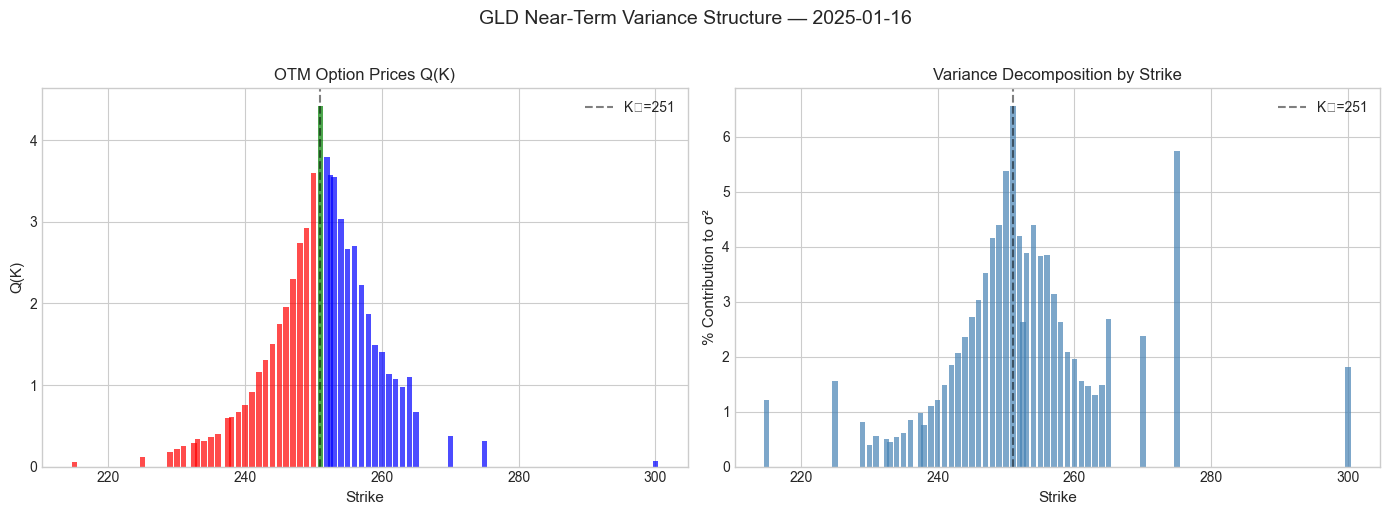


Top 5 contributing strikes:
  K=251: 6.55% of total variance
  K=275: 5.75% of total variance
  K=250: 5.38% of total variance
  K=249: 4.40% of total variance
  K=254: 4.39% of total variance


In [7]:
# Rebuild Q(K) for near-term and decompose
opts_near = opts_day[opts_day['expirationDate'] == near_exp].copy()
col_map = {'strikePrice': 'options-strikePrice', 'optionType': 'options-optiontype', 'settlement': 'options-priorSettle'}
opts_near = opts_near.rename(columns=col_map)

F1, K0_1 = compute_forward_and_k0(opts_near, result['r1'], result['T1'])
qk1 = build_qk(opts_near, K0_1)

decomp = variance_decomposition(qk1, result['r1'], result['T1'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Q(K) distribution
colors = ['red' if K < K0_1 else ('green' if K == K0_1 else 'blue') for K in qk1.index]
ax1.bar(qk1.index, qk1.values, color=colors, alpha=0.7, width=0.8)
ax1.axvline(x=K0_1, color='black', linestyle='--', alpha=0.5, label=f'K₀={K0_1:.0f}')
ax1.set_xlabel('Strike', fontsize=11)
ax1.set_ylabel('Q(K)', fontsize=11)
ax1.set_title('OTM Option Prices Q(K)', fontsize=12)
ax1.legend()

# Variance contribution
ax2.bar(decomp['strike'], decomp['pct_contribution'], color='steelblue', alpha=0.7, width=0.8)
ax2.axvline(x=K0_1, color='black', linestyle='--', alpha=0.5, label=f'K₀={K0_1:.0f}')
ax2.set_xlabel('Strike', fontsize=11)
ax2.set_ylabel('% Contribution to σ²', fontsize=11)
ax2.set_title('Variance Decomposition by Strike', fontsize=12)
ax2.legend()

fig.suptitle(f'GLD Near-Term Variance Structure — {trade_date}', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

print(f"\nTop 5 contributing strikes:")
top5 = decomp.nlargest(5, 'pct_contribution')
for _, row in top5.iterrows():
    print(f"  K={row['strike']:.0f}: {row['pct_contribution']:.2f}% of total variance")

## 7. Backtest Results

Run `python scripts/run_backtest.py` to generate the full VIX time series.

Results are saved in `output/`:
- `gld_vix_timeseries.csv` — VIX for each trade date
- `gld_vix_timeseries.png` — VIX vs Realized Vol chart
- `gld_vrp.png` — Variance Risk Premium

Backtest: 399 dates
VIX — Mean: 18.72%, Min: 10.55%, Max: 46.54%


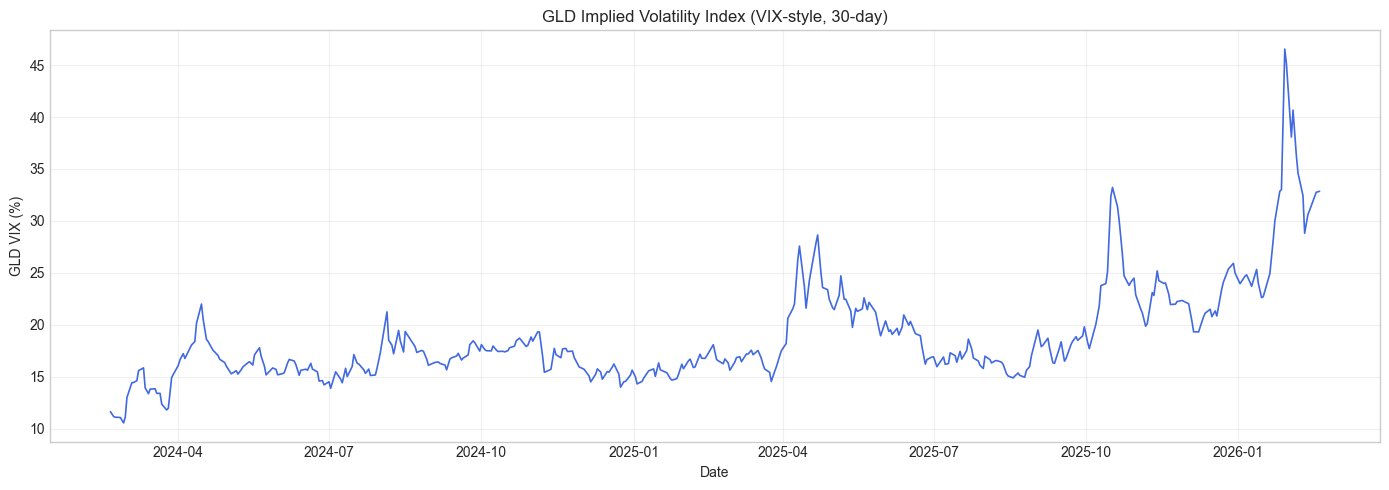

In [8]:
import os
csv_path = "output/gld_vix_timeseries.csv"
if os.path.exists(csv_path):
    vix_ts = pd.read_csv(csv_path)
    vix_ts['trade_date'] = pd.to_datetime(vix_ts['trade_date'])
    print(f"Backtest: {len(vix_ts)} dates")
    print(f"VIX — Mean: {vix_ts['vix'].mean():.2f}%, Min: {vix_ts['vix'].min():.2f}%, Max: {vix_ts['vix'].max():.2f}%")
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(vix_ts['trade_date'], vix_ts['vix'], color='royalblue', linewidth=1.2)
    ax.set_xlabel('Date')
    ax.set_ylabel('GLD VIX (%)')
    ax.set_title('GLD Implied Volatility Index (VIX-style, 30-day)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No backtest results found. Run: python scripts/run_backtest.py")